In [1]:
import os
import sys
current_dir = os.path.dirname(os.getcwd())
if not current_dir in sys.path:
    sys.path.append(current_dir)

# ----------------------------------------------------

In [2]:
import math
import torch
import numpy as np
import pandas as pd
import IR_UTE as ute
import phantom as pt
import torchkbnufft as tkbn
import randialSampling as rs
import matplotlib.pyplot as plt

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [3]:
dt = 10 # unite: us
t1_wm =  0.8  
t2_wm = 0.08
t1_myelin = 0.226         
t2_myelin = 300 * 1e-6
df = np.linspace(-500, 500, 200)

img_size = 256
n_readout = 4
t_readout = 0.768 * 1e-3 #s
t_nullout = int(0.55 * 1e6)

TE1 = 8 # us
TE2 = 2.5 * 1e3 # us

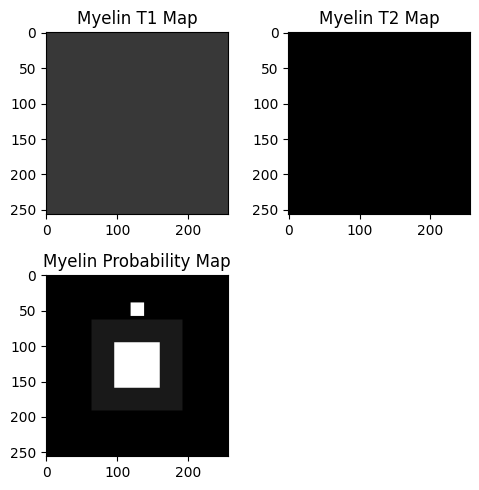

In [4]:
inner_myelin = 1
mixed_myelin = 0.1
outer_myelin = 0

myelin = pt.VirtualPhantom(img_size)
t1_map_myelin, t2_map_myelin, prob_map_myelin = myelin.create_maps(t1_myelin, t2_myelin, inner_myelin, mixed_myelin, outer_myelin, upper_sqaure=True)
myelin.phantom_display('Myelin')

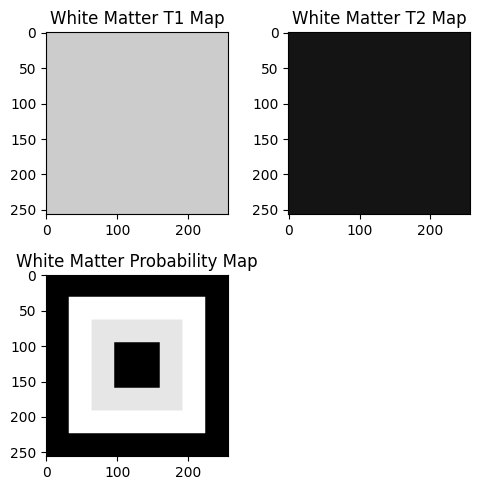

In [5]:
inner_wm = 0
mixed_wm = 0.9
outer_wm = 1

wm = pt.VirtualPhantom(img_size)
t1_map_wm, t2_map_wm, prob_map_wm = wm.create_maps(t1_wm, t2_wm, inner_wm, mixed_wm, outer_wm, upper_sqaure = True)
wm.phantom_display('White Matter')

In [6]:
class SNRCalc():
    def __init__(self, dt, df, t1_myelin, t2_myelin, t1_wm, t2_wm, img_size = 256, n_readout = 9, flip_angle = math.pi/2):
        self.dt = dt
        self.df = df
        self.t1_myelin = t1_myelin
        self.t2_myelin = t2_myelin
        self.t1_wm = t1_wm
        self.t2_wm = t2_wm
        self.img_size = img_size
        self.n_readout = n_readout
        self.flip_angle = flip_angle
        self.artefact_region_width = 10
        pass

    def combined_kdata_ktraj(self, t_readout, prob_map_myelin, prob_map_wm, TE, reverse_readout=False):
        print('white matter')
        wm = ute.IR_UTE(self.dt, self.df, self.t1_wm, self.t2_wm)
        self.TR = wm.TR
        _ = wm.inversion_recovery()
        t_nullout = wm.calculate_nulling_point()
        _, _, mag_readout_start_wm, _ = wm.transverse_excitation(self.n_readout, t_readout, t_nullout, self.flip_angle, TE)

        print()
        print('myelin')
        myelin = ute.IR_UTE(self.dt, self.df, self.t1_myelin, self.t2_myelin)
        _ = myelin.inversion_recovery()
        _, _, mag_readout_start_myelin, _ = myelin.transverse_excitation(self.n_readout, t_readout, t_nullout, self.flip_angle, TE)
        

        radial_sampling = rs.RadialSampling(self.img_size)
        self.nspokes = radial_sampling.nspokes
        kdata_t_myelin, ktraj_total = radial_sampling.get_kdata_ktraj(self.df, mag_readout_start_myelin, prob_map_myelin, self.n_readout, self.t2_myelin, t_readout, reverse_readout)
        kdata_t_wm, _ = radial_sampling.get_kdata_ktraj(self.df, mag_readout_start_wm, prob_map_wm, self.n_readout, self.t2_wm, t_readout, reverse_readout)
   
        kdata_total = kdata_t_myelin + kdata_t_wm
       
        print("flip_angle:", self.flip_angle)
        print("mag_readout_start_myelin:", mag_readout_start_myelin)
        print("mag_readout_start_wm:", mag_readout_start_wm)
        return kdata_total, ktraj_total
    
    def dual_echo_combined_kdata_ktraj(self, t_readout, prob_map_myelin, prob_map_wm, TE1, TE2):
        print('white matter')
        wm = ute.IR_UTE(self.dt, self.df, self.t1_wm, self.t2_wm)
        self.TR = wm.TR
        _ = wm.inversion_recovery()
        t_nullout = wm.calculate_nulling_point()
        _, _, mag_readout_start_wm_TE1, mag_readout_start_wm_TE2, _, _ = wm.transverse_excitation_dual_echo(self.n_readout, t_readout, t_nullout, self.flip_angle, TE1, TE2)
 

    
        print()
        print('myelin')
        myelin = ute.IR_UTE(self.dt, self.df, self.t1_myelin, self.t2_myelin)
        _ = myelin.inversion_recovery()
        _, _, mag_readout_start_myelin_TE1, mag_readout_start_myelin_TE2, _, _ = myelin.transverse_excitation_dual_echo(self.n_readout, t_readout, t_nullout, self.flip_angle, TE1, TE2)
        

        radial_sampling = rs.RadialSampling(self.img_size)
        self.nspokes = radial_sampling.nspokes
        kdata_t_myelin_TE1, ktraj_total_TE1 = radial_sampling.get_kdata_ktraj(self.df, mag_readout_start_myelin_TE1, prob_map_myelin, self.n_readout, self.t2_myelin, t_readout, reverse_readout = False)
        kdata_t_wm_TE1, _ = radial_sampling.get_kdata_ktraj(self.df, mag_readout_start_wm_TE1, prob_map_wm, self.n_readout, self.t2_wm, t_readout, reverse_readout = False)
        kdata_total_TE1 = kdata_t_myelin_TE1 + kdata_t_wm_TE1

        kdata_t_myelin_TE2, ktraj_total_TE2 = radial_sampling.get_kdata_ktraj(self.df, mag_readout_start_myelin_TE2, prob_map_myelin, self.n_readout, self.t2_myelin, t_readout, reverse_readout = True)
        kdata_t_wm_TE2, _ = radial_sampling.get_kdata_ktraj(self.df, mag_readout_start_wm_TE2, prob_map_wm, self.n_readout, self.t2_wm, t_readout, reverse_readout = True)
        kdata_total_TE2 = kdata_t_myelin_TE2 + kdata_t_wm_TE2
        print("flip_angle:", self.flip_angle)
        return kdata_total_TE1, ktraj_total_TE1, kdata_total_TE2, ktraj_total_TE2
    
    
    def SNR_CNR_calculation(self, kdata_total, ktraj_total, prob_map_myelin, prob_map_wm, blur=False):
        radial_sampling = rs.RadialSampling(self.img_size)
        if blur:
            # method 1: no density compensation (blurry image)
            image = radial_sampling.adjnufft_ob(kdata_total, ktraj_total)
        else:
            # method 2: use density compensation
            dcomp = tkbn.calc_density_compensation_function(ktraj=ktraj_total, im_size=(self.img_size, self.img_size))
            image = radial_sampling.adjnufft_ob(kdata_total * dcomp, ktraj_total)

    
        image_numpy = np.squeeze(image.cpu().numpy())
        print(image_numpy.shape)
        image_abs = np.abs(image_numpy) 

        noise_std = np.std(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])
        print(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])
        myelin_mean = np.mean(image_abs[(prob_map_myelin == 1) & (prob_map_wm == 0)])
        wm_mean = np.mean(image_abs[(prob_map_wm == 1) & (prob_map_myelin == 0)])

        print('noise_std:', noise_std)
        print('noise mean:', np.mean(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)]))
        print('myelin_mean:', myelin_mean)
        print('wm_mean:', wm_mean)
        
        snr_myelin = 0.66 * myelin_mean / noise_std
        snr_wm = 0.66 * wm_mean / noise_std
        cnr = 0.66 * abs(myelin_mean - wm_mean) / noise_std
        print("SNR_myelin:", snr_myelin)
        print("SNR_wm:", snr_wm)
        print('SNR Noise:', 0.66 * np.mean(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])/noise_std)



        # artefact region (Artefact to signal ratio) 5 roi
        ar = pt.VirtualPhantom(self.img_size)
        artefact_ROI = ar.create_artefact_ROI_region(self.artefact_region_width)
        background_mask = (prob_map_myelin == 0) & (prob_map_wm == 0) & (artefact_ROI == 0)
        #background_ROI = ar.create_background_ROI_region()
        artefact_ROI_mean = np.mean(image_abs[artefact_ROI == 1])
        #background_ROI_mean = np.percentile(image_abs[background_ROI == 1], 10)
        background_ROI_pctile = np.percentile(image_abs[background_mask], 10)
        asr = (artefact_ROI_mean - background_ROI_pctile)/myelin_mean
        print("artefact_ROI_mean:", artefact_ROI_mean)
        print("background_ROI_mean:", background_ROI_pctile)
        print("myelin mean:", myelin_mean)
        return  snr_myelin, snr_wm, cnr, asr
    
    def dual_echo_SNR_CNR_calculation(self, kdata_total_TE1, kdata_total_TE2, ktraj_total_TE1, ktraj_total_TE2, prob_map_myelin, prob_map_wm, blur=False):
        radial_sampling = rs.RadialSampling(self.img_size)
        if blur:
            # method 1: no density compensation (blurry image)
            image_TE1 = radial_sampling.adjnufft_ob(kdata_total_TE1, ktraj_total_TE1)
            image_TE2 = radial_sampling.adjnufft_ob(kdata_total_TE2, ktraj_total_TE2)
            image_numpy = np.squeeze(image_TE1.cpu().numpy()) - np.squeeze(image_TE2.cpu().numpy())
        else:
            # method 2: use density compensation
            dcomp_TE1 = tkbn.calc_density_compensation_function(ktraj=ktraj_total_TE1, im_size=(self.img_size, self.img_size))
            dcomp_TE2 = tkbn.calc_density_compensation_function(ktraj=ktraj_total_TE2, im_size=(self.img_size, self.img_size))
            image_TE1 = radial_sampling.adjnufft_ob(kdata_total_TE1 * dcomp_TE1, ktraj_total_TE1)
            image_TE2 = radial_sampling.adjnufft_ob(kdata_total_TE2 * dcomp_TE2, ktraj_total_TE2)
            image_numpy = np.squeeze(image_TE1.cpu().numpy()) - np.squeeze(image_TE2.cpu().numpy())

        print(image_numpy.shape)
        image_abs = np.abs(image_numpy) 

        noise_std = np.std(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])
        print(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])
        myelin_mean = np.mean(image_abs[(prob_map_myelin == 1) & (prob_map_wm == 0)])
        wm_mean = np.mean(image_abs[(prob_map_wm == 1) & (prob_map_myelin == 0)])
     

        print('noise_std:', noise_std)
        print('noise mean:', np.mean(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)]))
        print('myelin_mean:', myelin_mean)
        print('wm_mean:', wm_mean)
        
        snr_myelin = 0.66 * myelin_mean / noise_std
        snr_wm = 0.66 * wm_mean / noise_std
        cnr = 0.66 * abs(myelin_mean - wm_mean) / noise_std
        print("SNR_myelin:", snr_myelin)
        print("SNR_wm:", snr_wm)
        print('SNR Noise:', 0.66 * np.mean(image_abs[(prob_map_myelin == 0) & (prob_map_wm == 0)])/noise_std)

        # artefact region (Artefact to signal ratio) 1 roi
        # ar = pt.VirtualPhantom(self.img_size)
        # artefact_ROI = ar.create_artefact_ROI_region(self.artefact_region_width)
        # background_ROI = ar.create_background_ROI_region()
        # artefact_ROI_mean = np.mean(image_abs[artefact_ROI == 1])
        # background_ROI_mean = np.mean(image_abs[background_ROI == 1])
        # asr = (artefact_ROI_mean - background_ROI_mean)/myelin_mean
        # print("artefact_ROI_mean:", artefact_ROI_mean)
        # print("background_ROI_mean:", background_ROI_mean)
        # print("myelin mean:", myelin_mean)
        
        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(artefact_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Artefact ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()
        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(background_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Background ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()






        # artefact region (Artefact to signal ratio) 2 wm
        #ROI = np.zeros(self.img_size)
        #ROI[(prob_map_myelin == 0.1) & (prob_map_wm == 0.9)] = 1
        # mask = (prob_map_myelin == 0.1) & (prob_map_wm == 0.9)
        # ar = image_abs[mask]
        # cov = np.std(ar)/np.mean(ar)

        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(mask, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Artefact ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()




        
        # artefact region (Artefact to signal ratio) 3 background
        # mask = (prob_map_myelin == 0) & (prob_map_wm == 0)
        # ar = image_abs[mask]
        # cov = np.std(ar)/np.mean(ar)

        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(mask, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Artefact ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()





        # artefact region (Artefact to signal ratio) 4 myelin
        # mask = (prob_map_myelin == 1) & (prob_map_wm == 0)
        # ar = image_abs[mask]
        # cov = np.std(ar)/np.mean(ar)

        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(mask, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Artefact ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()




        # artefact region (Artefact to signal ratio) 5 roi
        ar = pt.VirtualPhantom(self.img_size)
        artefact_ROI = ar.create_artefact_ROI_region(self.artefact_region_width)
        background_mask = (prob_map_myelin == 0) & (prob_map_wm == 0) & (artefact_ROI == 0)
        #background_ROI = ar.create_background_ROI_region()
        artefact_ROI_mean = np.mean(image_abs[artefact_ROI == 1])
        #background_ROI_mean = np.percentile(image_abs[background_ROI == 1], 10)
        background_ROI_pctile = np.percentile(image_abs[background_mask], 10)
        asr = (artefact_ROI_mean - background_ROI_pctile)/myelin_mean
        print("artefact_ROI_mean:", artefact_ROI_mean)
        print("background_ROI_mean:", background_ROI_pctile)
        print("myelin mean:", myelin_mean)



        
        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(artefact_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Artefact ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()
        
        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(background_mask, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Background ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()

        # mask_below_10th = background_mask & (image_abs <= background_ROI_pctile)
        # plt.imshow(image_abs, cmap="gray")
        # plt.imshow(mask_below_10th, cmap="Reds", alpha=0.45)
        # plt.title("Background pixels below 10th percentile")
        # plt.axis("off")
        # plt.show()




        # # artefact region (Artefact to signal ratio) 6 artefact_roi_pctile_50 - bg_roi_pctile_5
        # ar = pt.VirtualPhantom(self.img_size)
        # artefact_ROI = ar.create_artefact_ROI_region(self.artefact_region_width)
        # background_mask = (prob_map_myelin == 0) & (prob_map_wm == 0) & (artefact_ROI == 0)
        # #background_ROI = ar.create_background_ROI_region()
        # artefact_ROI_mean = np.percentile(image_abs[artefact_ROI == 1],50)
        # #background_ROI_mean = np.percentile(image_abs[background_ROI == 1], 10)
        # background_ROI_pctile = np.percentile(image_abs[background_mask], 5)
        # asr = (artefact_ROI_mean - background_ROI_pctile)
        # print("artefact_ROI_mean:", artefact_ROI_mean)
        # print("background_ROI_mean:", background_ROI_pctile)
        # print("myelin mean:", myelin_mean)



        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(artefact_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Artefact ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()
        
        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(background_mask, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Background ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()





        # # artefact region (Artefact to signal ratio) 7 (artefact_roi_pctile_50 - bg_roi_pctile_5)/std(bg_roi_pctile_1to10)
        # ar = pt.VirtualPhantom(self.img_size)
        # artefact_ROI = ar.create_artefact_ROI_region(self.artefact_region_width)
        # background_mask = (prob_map_myelin == 0) & (prob_map_wm == 0) & (artefact_ROI == 0)
        # #background_ROI = ar.create_background_ROI_region()
        # artefact_ROI_mean = np.percentile(image_abs[artefact_ROI == 1],50)
        # #background_ROI_mean = np.percentile(image_abs[background_ROI == 1], 10)
        # background_ROI_pctile = np.percentile(image_abs[background_mask], 5)
        # # Compute lower and upper percentile thresholds
        # p1, p10 = np.percentile(image_abs[background_mask], [1, 10])

        # # Extract values within that range
        # values_1_to_10 = image_abs[background_mask][
        #         (image_abs[background_mask] >= p1) & (image_abs[background_mask] <= p10)]
        # asr = (artefact_ROI_mean - background_ROI_pctile)/np.std(values_1_to_10)
        # print("artefact_ROI_mean:", artefact_ROI_mean)
        # print("background_ROI_mean:", background_ROI_pctile)
        # print("myelin mean:", myelin_mean)



        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(artefact_ROI, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Artefact ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()
        
        # plt.imshow(np.absolute(image_abs), cmap='gray')
        # plt.imshow(background_mask, cmap='jet', alpha=0.4)  # overlay with transparency
        # plt.title('Background ROI for ASR Calculation')
        # plt.colorbar()
        # plt.axis('on')
        # plt.show()

 
        
        return  snr_myelin, snr_wm, cnr, asr
    
    
    
    def total_acquisation_time_calc(self, TR):
        """
        TR: repetition time in ms
        """
        radial_sampling = rs.RadialSampling(self.img_size)
        nspokes = radial_sampling.nspokes

        n_TR = np.ceil(nspokes / self.n_readout)
        total_TA = n_TR * TR
        return total_TA




## (1) Plot flip angle vs SNR across different n_readout

### Without dual echo

In [7]:
import math

import matplotlib.pyplot as plt

def readout_angle_pairs_display(n_readout_list, angles_deg_list, TE, reverse_readout = False):
    flip_angle_list = [angle * torch.pi / 180 for angle in angles_deg_list]

    n_plots = len(n_readout_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))

    if n_plots == 1:
        axes = [axes]

    results = []
    for ax, n_readout in zip(axes, n_readout_list):
        snr_myelin_list, snr_wm_list, cnr_list, total_TA_list, asr_list = [], [], [], [],[]
        
        for index, flip_angle in enumerate(flip_angle_list):
            combined = SNRCalc(
                dt, df,
                t1_myelin, t2_myelin,
                t1_wm, t2_wm,
                img_size=img_size,
                n_readout=n_readout,
                flip_angle=flip_angle
            )
            
            kdata_total, ktraj_total = combined.combined_kdata_ktraj(
                t_readout, prob_map_myelin, prob_map_wm, TE, reverse_readout
            )

            snr_myelin, snr_wm, cnr,asr = combined.SNR_CNR_calculation(
                kdata_total, ktraj_total, prob_map_myelin, prob_map_wm
            )
            TR = combined.TR
            total_TA = combined.total_acquisation_time_calc(TR) * 1e-6
            
            snr_myelin_list.append(snr_myelin)
            snr_wm_list.append(snr_wm)
            cnr_list.append(cnr)
            total_TA_list.append(total_TA)
            asr_list.append(asr)

            results.append({
            "n_readout": n_readout,
            "flip_angle": angles_deg_list[index],
            "snr_myelin": snr_myelin,
            "snr_wm": snr_wm,
            "cnr": cnr,
            "TA (min)": np.round(total_TA/60,2) ,
            "efficiency": cnr / math.sqrt(total_TA),
            "asr": asr})


        ax.plot(angles_deg_list, snr_myelin_list, label='Myelin SNR')
        ax.plot(angles_deg_list, snr_wm_list, label='WM SNR')
        ax.set_title(f'n_readout = {n_readout}')
        ax.set_ylim([0,50])
        ax.set_ylabel('SNR') 
        ax.set_xlabel('Flip angle (deg)')
        ax.legend()
        ax.grid(True)

    # axes[0].set_ylabel('SNR')


    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(results)
    table.to_csv("cnr_efficiency_table_single_echo40.csv")



white matter
t_readout_end_index: 201
write_start: 0
initial_mag: [-7.53371575e-06  1.53826129e-05 -1.89362292e-06]
Angle=0.17453292519943295, M after 1 step: [-7.53520213e-06  1.53825026e-05  1.06019686e-05]
write_start: 201
initial_mag: [0.         0.         0.00250097]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 7.11498057e-07 2.51344341e-03]
write_start: 402
initial_mag: [0.         0.         0.00496118]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 1.40791779e-06 4.97362102e-03]
write_start: 603
initial_mag: [0.         0.         0.00737681]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 2.09171813e-06 7.38921926e-03]
write_start: 804
initial_mag: [0.         0.         0.00974867]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 2.76312774e-06 9.76104594e-03]
write_start: 1005
initial_mag: [0.         0.         0.01207755]
Angle=0.17453292519943295, M after 1 step: [0.00000000e+00 3.42237116e-06 1.20898942e-02]
write_start: 12

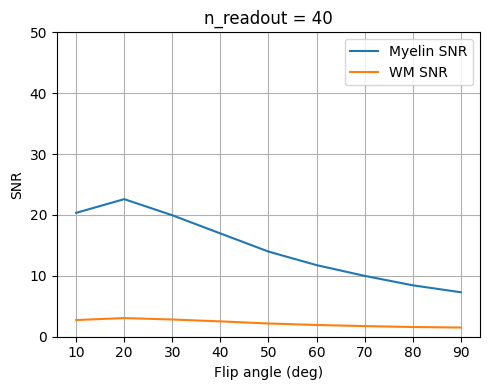

In [8]:
angles_deg_list = [10,20,30,40,50,60, 70, 80, 90]
#angles_deg_list = [30]
n_readout_list = [40] 
# n_readout_list = [20, 25, 30, 40] 
#TR = 1000 # ms --> Change TR in IR_UTE
readout_angle_pairs_display(n_readout_list, angles_deg_list, TE1, reverse_readout=False)

### Dual-echo

In [ ]:
import math

import matplotlib.pyplot as plt

def readout_angle_pairs_display(n_readout_list, angles_deg_list, TE1, TE2):
    flip_angle_list = [angle * torch.pi / 180 for angle in angles_deg_list]

    n_plots = len(n_readout_list)
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 4))

    if n_plots == 1:
        axes = [axes]

    results = []
    for ax, n_readout in zip(axes, n_readout_list):
        snr_myelin_list, snr_wm_list, cnr_list, total_TA_list, asr_list = [], [], [], [], []
        
        for index, flip_angle in enumerate(flip_angle_list):
            combined = SNRCalc(
                dt, df,
                t1_myelin, t2_myelin,
                t1_wm, t2_wm,
                img_size=img_size,
                n_readout=n_readout,
                flip_angle=flip_angle
            )
            
            kdata_total_TE1, ktraj_total_TE1, kdata_total_TE2, ktraj_total_TE2 = combined.dual_echo_combined_kdata_ktraj(
                t_readout, prob_map_myelin, prob_map_wm, TE1, TE2
            )
            # kdata_total_TE2, ktraj_total_TE2 = combined.dual_echo_combined_kdata_ktraj(
            #     t_readout, prob_map_myelin, prob_map_wm, TE2, reverse_readout= True
            # )

            snr_myelin, snr_wm, cnr, asr = combined.dual_echo_SNR_CNR_calculation(
                kdata_total_TE1, kdata_total_TE2, ktraj_total_TE1, ktraj_total_TE2, prob_map_myelin, prob_map_wm
            )
            TR = combined.TR
            total_TA = combined.total_acquisation_time_calc(TR) * 1e-6
            
            snr_myelin_list.append(snr_myelin)
            snr_wm_list.append(snr_wm)
            cnr_list.append(cnr)
            total_TA_list.append(total_TA)
            asr_list.append(asr)

            results.append({
            "n_readout": n_readout,
            "flip_angle": angles_deg_list[index],
            "snr_myelin": snr_myelin,
            "snr_wm": snr_wm,
            "cnr": cnr,
            "TA (min)": np.round(total_TA/60,2) ,
            "efficiency": cnr / math.sqrt(total_TA),
            "asr": asr})


        ax.plot(angles_deg_list, snr_myelin_list, label='Myelin SNR')
        ax.plot(angles_deg_list, snr_wm_list, label='WM SNR')
        ax.set_title(f'n_readout = {n_readout}')
        ax.set_ylim([0,50])
        ax.set_ylabel('SNR') 
        ax.set_xlabel('Flip angle (deg)')
        ax.legend()
        ax.grid(True)

    # axes[0].set_ylabel('SNR')


    plt.tight_layout()
    plt.show()

    table = pd.DataFrame(results)
    table.to_csv("cnr_efficiency_table_dual_echo1-15.csv")


white matter
t_readout_end_index: 527
write_start: 0
initial_mag: [-7.22166239e-06  1.56509183e-05  3.57923046e-08]
Angle=0.17453292519943295, M after 1 step: [-7.22323014e-06  1.56513889e-05  1.25312599e-05]

myelin
t_readout_end_index: 527
write_start: 0
initial_mag: [-7.41098469e-323 -7.41098469e-323  9.06136003e-001]
Angle=0.17453292519943295, M after 1 step: [-7.41098469e-323  2.56116509e-004  9.06140120e-001]
flip_angle: 0.17453292519943295
(256, 256)
[211.10611879 159.41823003 171.93579248 ... 267.18343687 138.8886643
  84.72902871]
noise_std: 37.55142215866279
noise mean: 68.98383844469251
myelin_mean: 1189.8802103697776
wm_mean: 63.07450282664379
SNR_myelin: 20.913214299205617
SNR_wm: 1.108591085836716
SNR Noise: 1.2124529713182604
artefact_ROI_mean: 65.69535780634897
background_ROI_mean: 25.065979138497816
myelin mean: 1189.8802103697776
white matter
t_readout_end_index: 527
write_start: 0
initial_mag: [-7.81999961e-06  1.51378506e-05 -3.59226532e-06]
Angle=0.3490658503988659

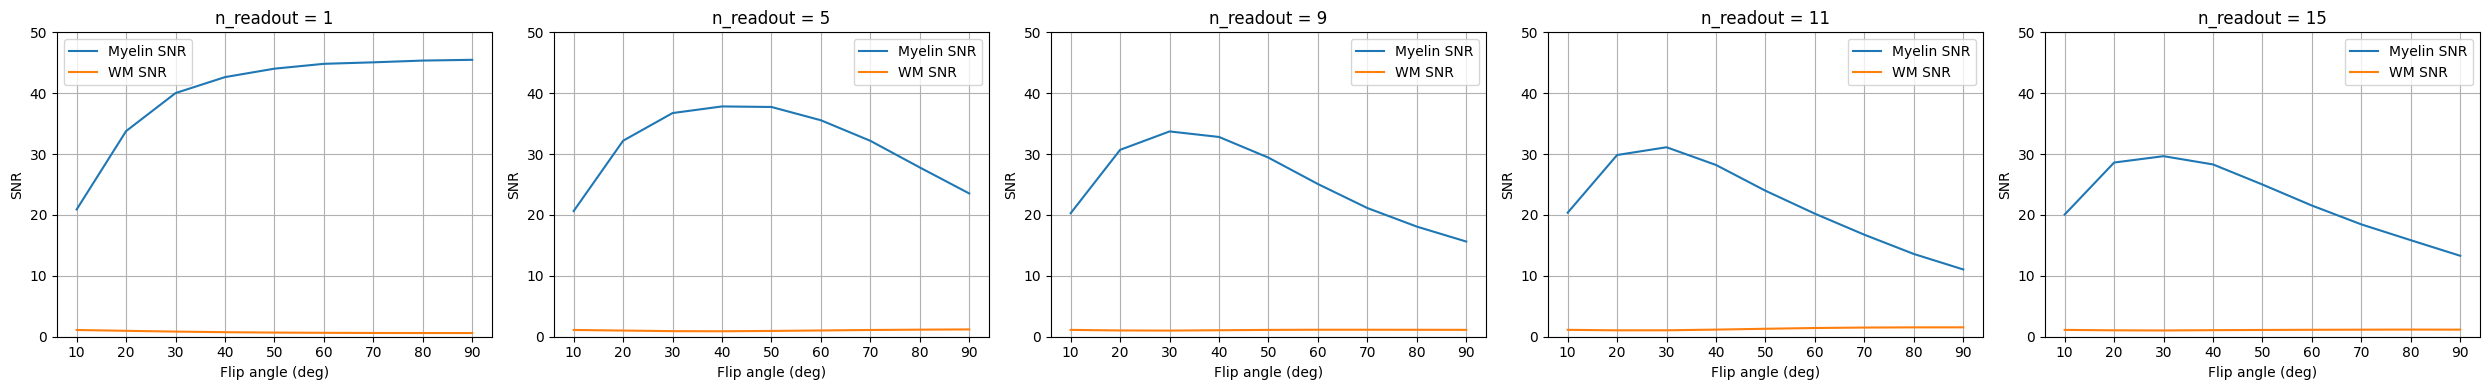

In [11]:
angles_deg_list = [10,20,30,40,50,60,70,80,90]
#angles_deg_list = [10,20,30,60,80,90]
n_readout_list = [1,5, 9, 11, 15] 
n_readout_list = [60] 
n_readout_list = [1, 5, 9, 11, 15] 
#n_readout_list = [1] 
#n_readout_list = [20, 25, 30, 40] 

#TR = 1000 # ms --> Change TR in IR_UTE
readout_angle_pairs_display(n_readout_list, angles_deg_list, TE1, TE2)

## (2) Visualize CNR efficiency (create table and heatmaps)

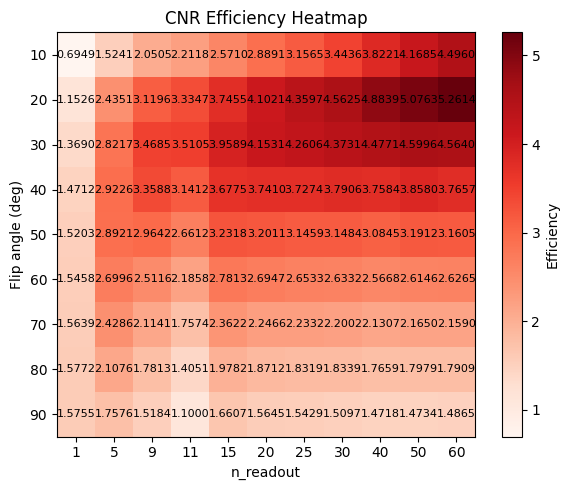

In [9]:
import pandas as pd

df = pd.read_csv("cnr_efficiency_table_dual_echo.csv")

# (1) Save pivot efficiency table
pivot_eff = df.pivot(
    index="flip_angle",   
    columns="n_readout",      
    values="efficiency"       
)
pivot_eff = pivot_eff.sort_index().sort_index(axis=1)
pivot_eff.to_csv("pivot_efficiency.csv")


# (2) Plot CNR efficiency across different n_readout and flip angles
plt.figure(figsize=(6, 5))
im = plt.imshow(pivot_eff, aspect='auto', cmap='Reds')
plt.colorbar(im, label='Efficiency')
plt.xticks(range(len(pivot_eff.columns)), pivot_eff.columns)
plt.yticks(range(len(pivot_eff.index)), pivot_eff.index)

# Add values inside cells 
for i in range(len(pivot_eff.index)):
    for j in range(len(pivot_eff.columns)):
        val = pivot_eff.iloc[i, j]
        plt.text(j, i, f"{val:.4f}", ha='center', va='center', fontsize=8)

plt.xlabel('n_readout')
plt.ylabel('Flip angle (deg)')
plt.title('CNR Efficiency Heatmap')

plt.tight_layout()
plt.show()

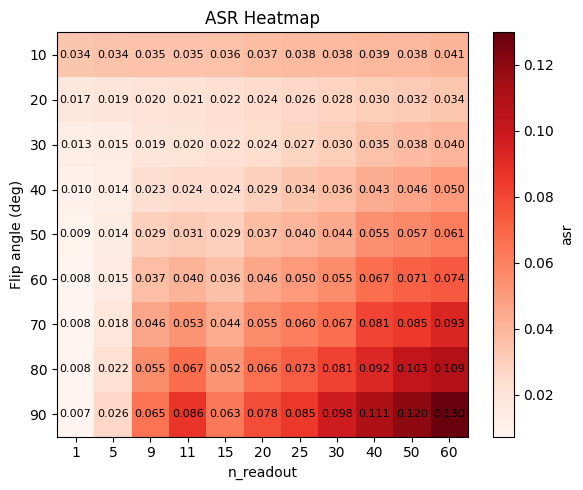

In [ ]:
import pandas as pd

df = pd.read_csv("cnr_efficiency_table_dual_echo.csv")

# (1) Save pivot efficiency table
pivot_eff = df.pivot(
    index="flip_angle",   
    columns="n_readout",      
    values="asr"       
)
pivot_eff = pivot_eff.sort_index().sort_index(axis=1)
pivot_eff.to_csv("pivot_asr_artefact_dual_echo.csv")


# (2) Plot ASR  across different n_readout and flip angles
plt.figure(figsize=(6, 5))
im = plt.imshow(pivot_eff, aspect='auto', cmap='Reds')
plt.colorbar(im, label='asr')
plt.xticks(range(len(pivot_eff.columns)), pivot_eff.columns)
plt.yticks(range(len(pivot_eff.index)), pivot_eff.index)

# Add values inside cells 
for i in range(len(pivot_eff.index)):
    for j in range(len(pivot_eff.columns)):
        val = pivot_eff.iloc[i, j]
        plt.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8)

plt.xlabel('n_readout')
plt.ylabel('Flip angle (deg)')
plt.title('ASR Heatmap')

plt.tight_layout()
plt.show()

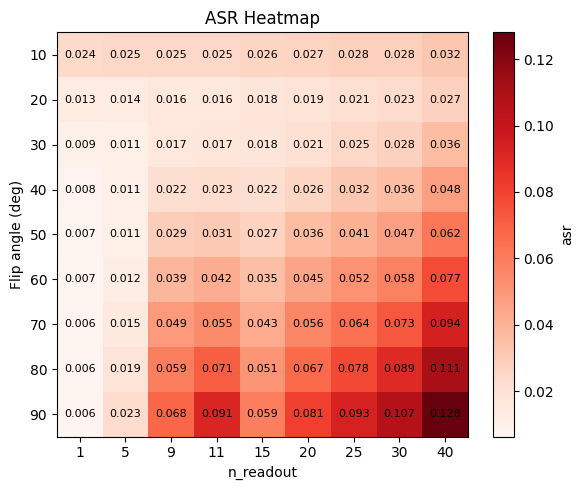

In [12]:
import pandas as pd

df = pd.read_csv("cnr_efficiency_table_single_echo.csv")

# (1) Save pivot efficiency table
pivot_eff = df.pivot(
    index="flip_angle",   
    columns="n_readout",      
    values="asr"       
)
pivot_eff = pivot_eff.sort_index().sort_index(axis=1)
pivot_eff.to_csv("pivot_asr_artefact_single_echo.csv")


# (2) Plot ASR  across different n_readout and flip angles
plt.figure(figsize=(6, 5))
im = plt.imshow(pivot_eff, aspect='auto', cmap='Reds')
plt.colorbar(im, label='asr')
plt.xticks(range(len(pivot_eff.columns)), pivot_eff.columns)
plt.yticks(range(len(pivot_eff.index)), pivot_eff.index)

# Add values inside cells 
for i in range(len(pivot_eff.index)):
    for j in range(len(pivot_eff.columns)):
        val = pivot_eff.iloc[i, j]
        plt.text(j, i, f"{val:.3f}", ha='center', va='center', fontsize=8)

plt.xlabel('n_readout')
plt.ylabel('Flip angle (deg)')
plt.title('ASR Heatmap')

plt.tight_layout()
plt.show()

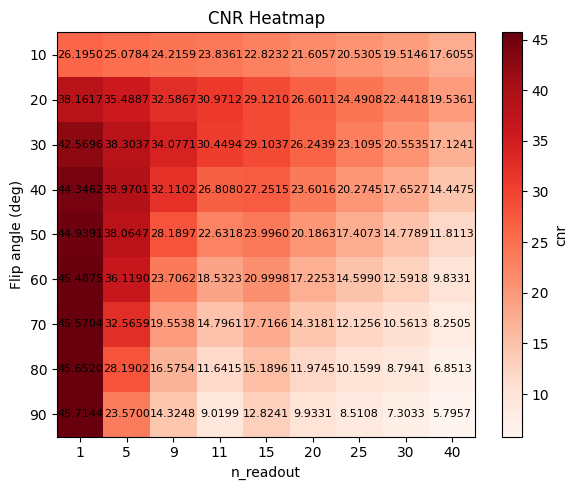

In [11]:
import pandas as pd

df = pd.read_csv("cnr_efficiency_table_single_echo.csv")

# (1) Save pivot efficiency table
pivot_eff = df.pivot(
    index="flip_angle",   
    columns="n_readout",      
    values="cnr"       
)
pivot_eff = pivot_eff.sort_index().sort_index(axis=1)
pivot_eff.to_csv("pivot_cnr_single_echo.csv")


# (2) Plot CNR efficiency across different n_readout and flip angles
plt.figure(figsize=(6, 5))
im = plt.imshow(pivot_eff, aspect='auto', cmap='Reds')
plt.colorbar(im, label='cnr')
plt.xticks(range(len(pivot_eff.columns)), pivot_eff.columns)
plt.yticks(range(len(pivot_eff.index)), pivot_eff.index)

# Add values inside cells 
for i in range(len(pivot_eff.index)):
    for j in range(len(pivot_eff.columns)):
        val = pivot_eff.iloc[i, j]
        plt.text(j, i, f"{val:.4f}", ha='center', va='center', fontsize=8)

plt.xlabel('n_readout')
plt.ylabel('Flip angle (deg)')
plt.title('CNR Heatmap')

plt.tight_layout()
plt.show()

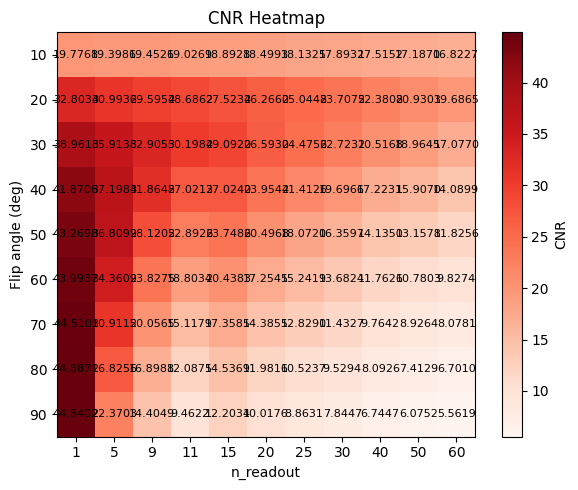

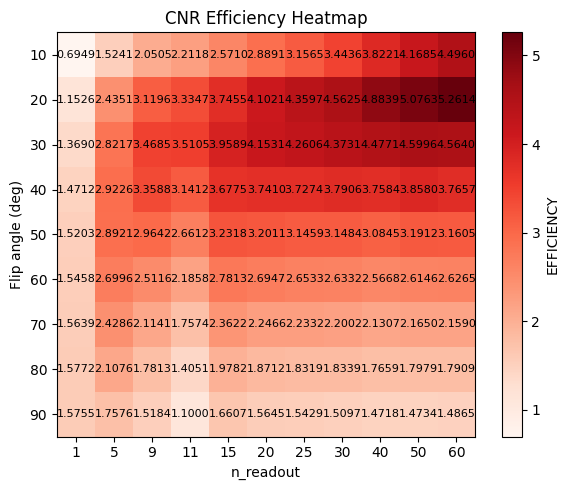

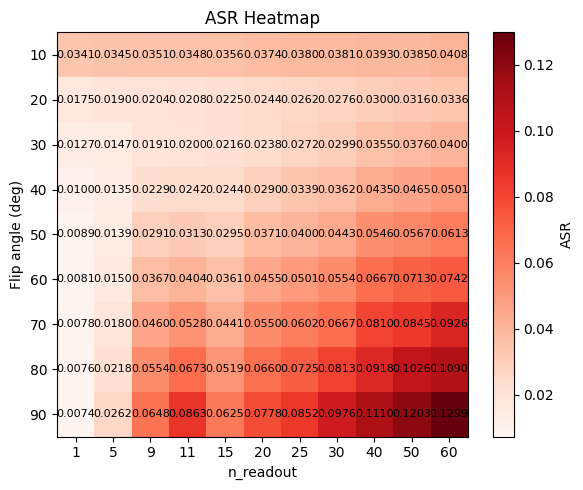

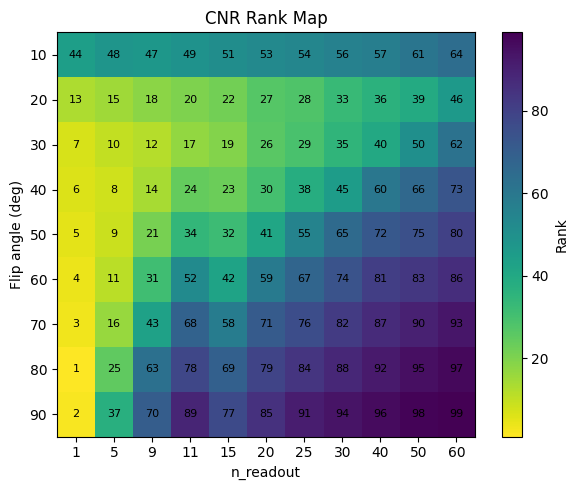

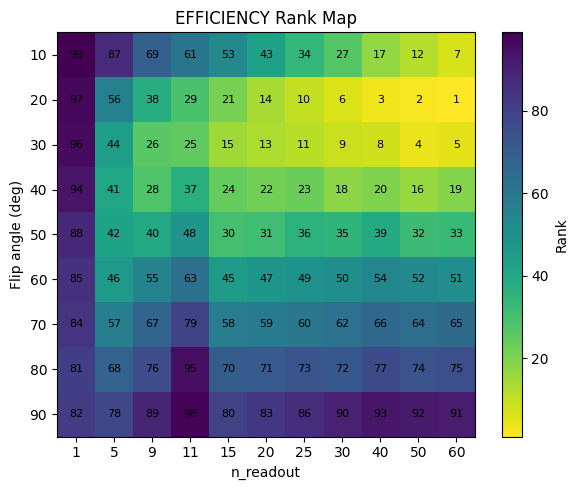

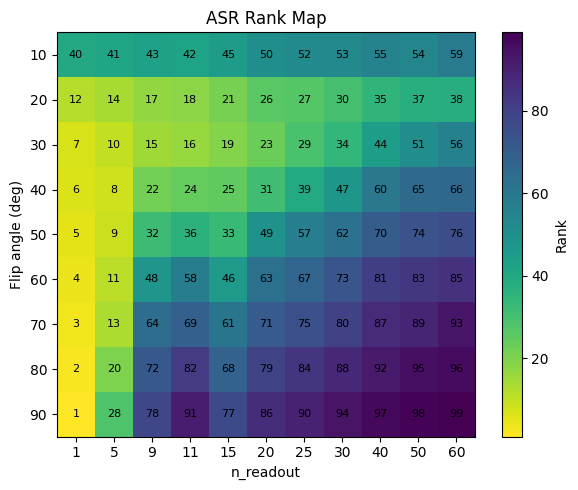

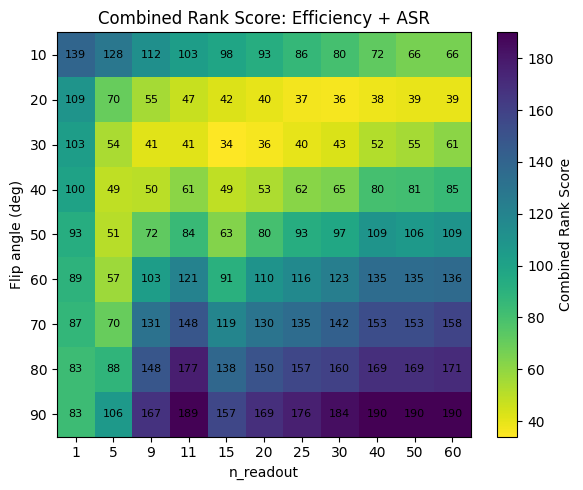

Best combination:
Flip angle = 30
n_readout = 15
Combined rank score = 34


In [40]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("cnr_efficiency_table_dual_echo.csv")

metrics = ["cnr", "efficiency", "asr"]
titles = ['CNR', 'CNR Efficiency', 'ASR']

pivot_tables = {}
rank_tables = {}

# ---------- Heatmaps ----------
for j, metric in enumerate(metrics):
    title = titles[j]
    pivot = (
        df.pivot(
            index="flip_angle",
            columns="n_readout",
            values=metric
        )
        .sort_index()
        .sort_index(axis=1)
    )

    pivot_tables[metric] = pivot

    plt.figure(figsize=(6, 5))
    im = plt.imshow(pivot, aspect="auto", cmap="Reds")
    plt.colorbar(im, label=metric.upper())

    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)

    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            plt.text(
                j, i,
                f"{pivot.iloc[i, j]:.4f}",
                ha="center",
                va="center",
                fontsize=8
            )
    
    plt.xlabel("n_readout")
    plt.ylabel("Flip angle (deg)")
    plt.title(f"{title} Heatmap")
    plt.tight_layout()
    plt.show()


# ---------- Rank maps ----------
for metric in metrics:

    pivot = pivot_tables[metric]

    if metric == "asr":
        # For ASR: highest value gets largest rank
        rank_map = (
            pivot.stack()
            .rank(ascending=True, method="min")
            .unstack()
        )
    else:
        # For CNR and efficiency: highest value gets smallest rank
        rank_map = (
            pivot.stack()
            .rank(ascending=False, method="min")
            .unstack()
        )

    rank_tables[metric] = rank_map

    plt.figure(figsize=(6, 5))
    im = plt.imshow(rank_map, aspect="auto", cmap="viridis_r")
    plt.colorbar(im, label="Rank")

    plt.xticks(range(len(rank_map.columns)), rank_map.columns)
    plt.yticks(range(len(rank_map.index)), rank_map.index)

    for i in range(len(rank_map.index)):
        for j in range(len(rank_map.columns)):
            plt.text(
                j, i,
                f"{int(rank_map.iloc[i, j])}",
                ha="center",
                va="center",
                fontsize=8
            )

    plt.xlabel("n_readout")
    plt.ylabel("Flip angle (deg)")
    plt.title(f"{metric.upper()} Rank Map")
    plt.tight_layout()
    plt.show()


# ---------- Sum of ranks ----------
# CNR and efficiency: lower rank is better
# ASR: higher rank is better, so subtract ASR rank
rank_sum = (
   
    rank_tables["efficiency"]
    + rank_tables["asr"]
)

plt.figure(figsize=(6, 5))
im = plt.imshow(rank_sum, aspect="auto", cmap="viridis_r")
plt.colorbar(im, label="Combined Rank Score")

plt.xticks(range(len(rank_sum.columns)), rank_sum.columns)
plt.yticks(range(len(rank_sum.index)), rank_sum.index)

for i in range(len(rank_sum.index)):
    for j in range(len(rank_sum.columns)):
        plt.text(
            j, i,
            f"{int(rank_sum.iloc[i, j])}",
            ha="center",
            va="center",
            fontsize=8
        )

plt.xlabel("n_readout")
plt.ylabel("Flip angle (deg)")
plt.title("Combined Rank Score: Efficiency + ASR")
plt.tight_layout()
plt.show()


# ---------- Print best combination ----------
# Lower combined score is better
best_idx = rank_sum.stack().idxmin()

print("Best combination:")
print(f"Flip angle = {best_idx[0]}")
print(f"n_readout = {best_idx[1]}")
print(f"Combined rank score = {int(rank_sum.loc[best_idx[0], best_idx[1]])}")

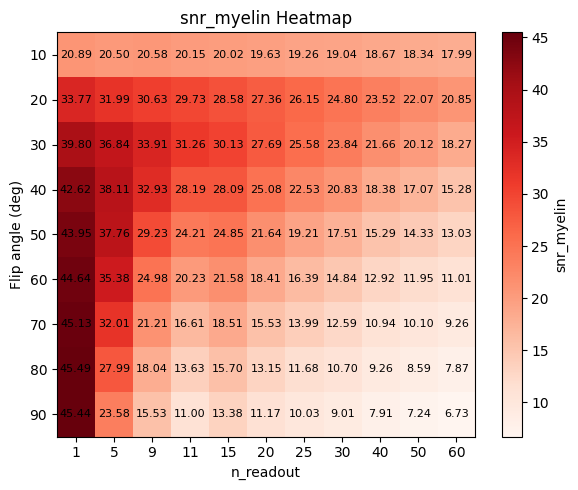

In [17]:
import pandas as pd

df = pd.read_csv("cnr_efficiency_table_dual_echo.csv")

# (1) Save pivot efficiency table
pivot_eff = df.pivot(
    index="flip_angle",   
    columns="n_readout",      
    values="snr_myelin"       
)
pivot_eff = pivot_eff.sort_index().sort_index(axis=1)
pivot_eff.to_csv("pivot_efficiency_dual_echo.csv")


# (2) Plot CNR efficiency across different n_readout and flip angles
plt.figure(figsize=(6, 5))
im = plt.imshow(pivot_eff, aspect='auto', cmap='Reds')
plt.colorbar(im, label='snr_myelin')
plt.xticks(range(len(pivot_eff.columns)), pivot_eff.columns)
plt.yticks(range(len(pivot_eff.index)), pivot_eff.index)

# Add values inside cells 
for i in range(len(pivot_eff.index)):
    for j in range(len(pivot_eff.columns)):
        val = pivot_eff.iloc[i, j]
        plt.text(j, i, f"{val:.2f}", ha='center', va='center', fontsize=8)

plt.xlabel('n_readout')
plt.ylabel('Flip angle (deg)')
plt.title('snr_myelin Heatmap')

plt.tight_layout()
plt.show()